In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

survival_df = pd.read_csv("TCGA_data/survival_data.txt", sep="\t")
phenotype_df = pd.read_csv("TCGA_data/survival_full_set.csv")

merged_df = survival_df.merge(
    phenotype_df,
    on="sample",
    how="inner"
)

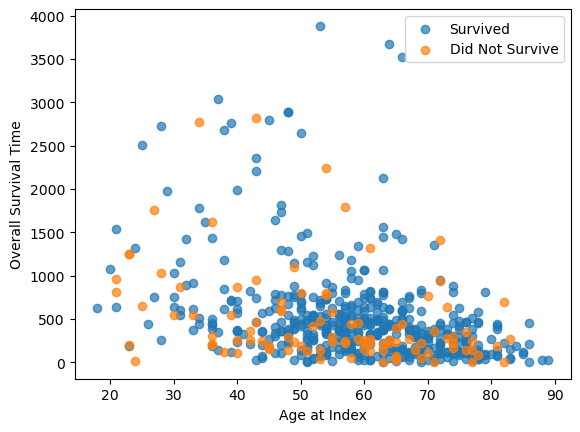

In [3]:
# Split by survival status
survived = merged_df[merged_df['OS'] == 1]
not_survived = merged_df[merged_df['OS'] == 0]

# Plot
plt.scatter(
    survived['age_at_index.demographic'],
    survived['OS.time'],
    label="Survived",
    alpha=0.7
)

plt.scatter(
    not_survived['age_at_index.demographic'],
    not_survived['OS.time'], 
    label="Did Not Survive",
    alpha=0.7
)

plt.xlabel("Age at Index")
plt.ylabel("Overall Survival Time")
plt.legend()
plt.show()

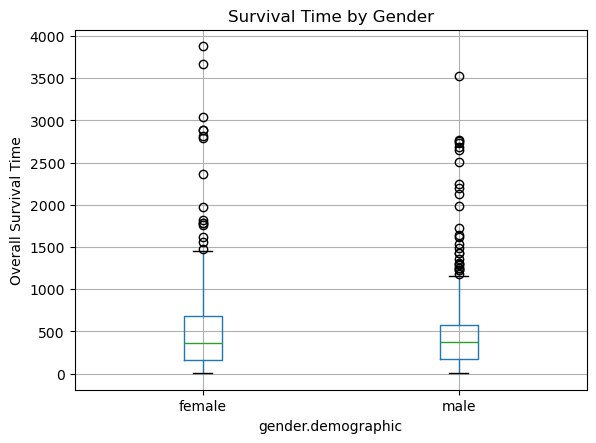

In [4]:
merged_df.boxplot(column='OS.time', by='gender.demographic')
plt.ylabel("Overall Survival Time")
plt.title("Survival Time by Gender")
plt.suptitle("")
plt.show()

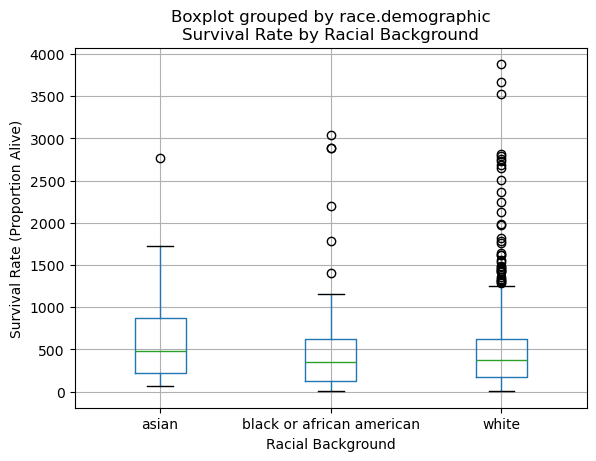

In [5]:
# Calculate survival rate by gender
merged_df.boxplot(column='OS.time', by='race.demographic')
plt.ylabel("Survival Rate (Proportion Alive)")
plt.xlabel("Racial Background")
plt.title("Survival Rate by Racial Background")
plt.show()

In [6]:

RT_df = merged_df[merged_df['treatment_or_therapy.treatments.diagnoses'] == "RT"]
TMZ_df = merged_df[merged_df["treatment_or_therapy.treatments.diagnoses"] == "TMZ"]
RT_and_TMZ_df = merged_df[merged_df["treatment_or_therapy.treatments.diagnoses"] == "RT/TMZ"]
no_treatment_df = merged_df[merged_df["treatment_or_therapy.treatments.diagnoses"] == "no treatment"]

#print(RT_df.head())

<Figure size 640x480 with 0 Axes>

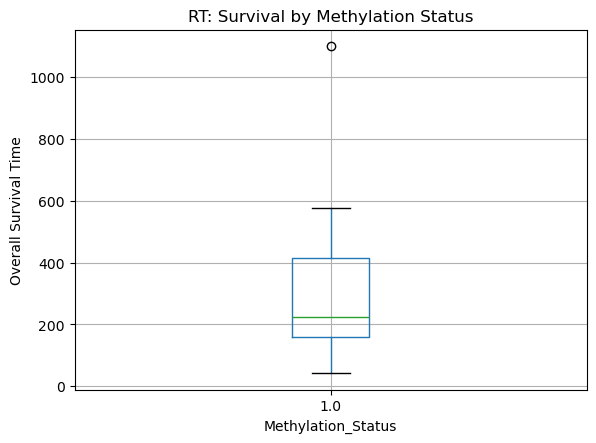

<Figure size 640x480 with 0 Axes>

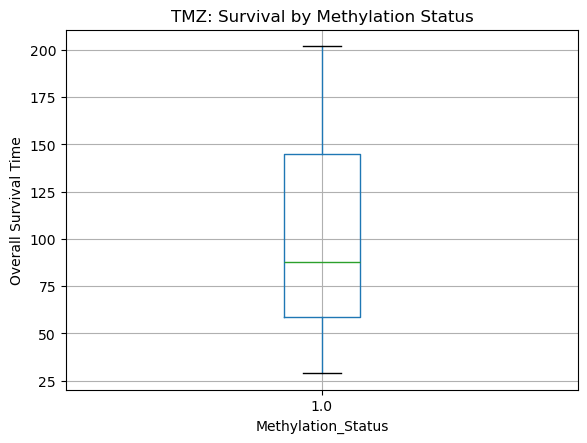

<Figure size 640x480 with 0 Axes>

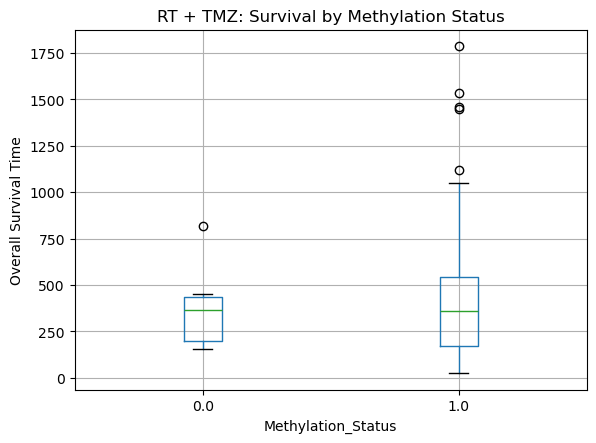

<Figure size 640x480 with 0 Axes>

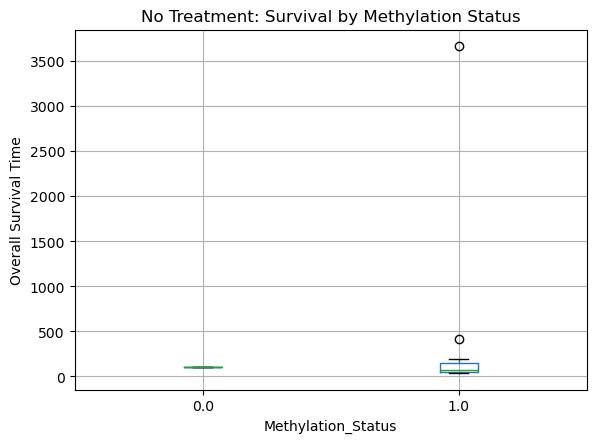

In [7]:
groups = {
    "RT": RT_df,
    "TMZ": TMZ_df,
    "RT + TMZ": RT_and_TMZ_df,
    "No Treatment": no_treatment_df
}


for name, df in groups.items():
    if len(df) > 0:
        plt.figure()
        df.boxplot(column='OS.time', by='Methylation_Status')
        plt.title(f"{name}: Survival by Methylation Status")
        plt.suptitle("")
        plt.ylabel("Overall Survival Time")
        plt.show()

In [8]:
print("RT methylation counts:")
print(RT_df['Methylation_Status'].value_counts())

print("\nTMZ methylation counts:")
print(TMZ_df['Methylation_Status'].value_counts())

print("\n RT/TMZ methylation counts:")
print(RT_and_TMZ_df['Methylation_Status'].value_counts())

print("\n no treatment methylation counts:")
print(no_treatment_df['Methylation_Status'].value_counts())

RT methylation counts:
Methylation_Status
1.0    7
Name: count, dtype: int64

TMZ methylation counts:
Methylation_Status
1.0    3
Name: count, dtype: int64

 RT/TMZ methylation counts:
Methylation_Status
1.0    86
0.0     7
Name: count, dtype: int64

 no treatment methylation counts:
Methylation_Status
1.0    13
0.0     1
Name: count, dtype: int64


In [9]:
# ── Kaplan-Meier Setup ──────────────────────────────────────────────────────
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# --- Event encoding ---
merged_df["event"] = merged_df["vital_status.demographic"].map({
    "Dead": 1,
    "Alive": 0
})

# --- Clean OS.time ---
merged_df["OS.time"] = pd.to_numeric(merged_df["OS.time"], errors="coerce")

# --- Drop missing required fields ---
merged_df = merged_df.dropna(subset=["OS.time", "event", "Methylation_Status"])

# --- TMZ group classification ---
def classify_tmz(val):
    val_str = str(val).lower()
    if "tmz" in val_str or "temozolomide" in val_str:
        return "TMZ"        # catches both "TMZ" and "RT/TMZ"
    else:
        return "Non-TMZ"    # catches RT alone, no treatment, etc.

merged_df["TMZ_group"] = merged_df[
    "treatment_or_therapy.treatments.diagnoses"
].apply(classify_tmz)

# --- Sanity checks ---
print("TMZ group counts:")
print(merged_df["TMZ_group"].value_counts())
print("\nOS.time dtype:", merged_df["OS.time"].dtype)
print("event dtype:  ", merged_df["event"].dtype)
print("\nGroup sizes:")
print(merged_df.groupby("TMZ_group").size())
print("\nUnique treatment values:")
print(merged_df["treatment_or_therapy.treatments.diagnoses"].unique())

TMZ group counts:
TMZ_group
TMZ        95
Non-TMZ    30
Name: count, dtype: int64

OS.time dtype: float64
event dtype:   float64

Group sizes:
TMZ_group
Non-TMZ    30
TMZ        95
dtype: int64

Unique treatment values:
['RT/TMZ' 'TMZ' 'no treatment' 'RT' "['not reported', 'not reported']"
 "['yes', 'not reported']"]


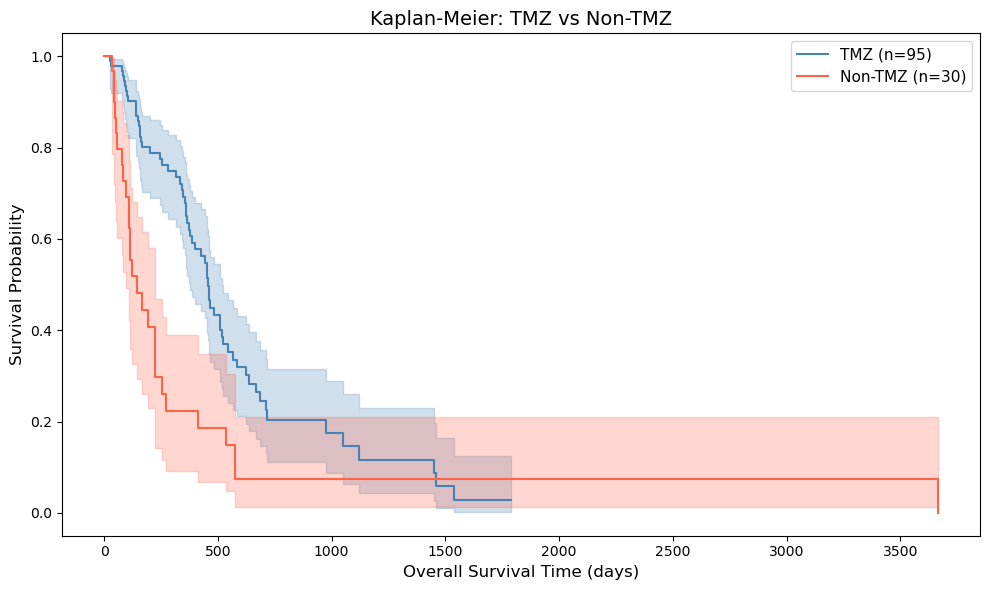

In [10]:
# ── Kaplan-Meier Analysis ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

kmf = KaplanMeierFitter()
colors = {"TMZ": "steelblue", "Non-TMZ": "tomato"}

plt.figure(figsize=(10, 6))

for group in ["TMZ", "Non-TMZ"]:
    subset = merged_df[merged_df["TMZ_group"] == group]
    if len(subset) == 0:
        print(f"Warning: No patients found in group '{group}'")
        continue
    kmf.fit(
        durations=subset["OS.time"],
        event_observed=subset["event"],
        label=f"{group} (n={len(subset)})"
    )
    kmf.plot_survival_function(ci_show=True, color=colors[group])


# --- Plot formatting ---
plt.title("Kaplan-Meier: TMZ vs Non-TMZ", fontsize=14)
plt.xlabel("Overall Survival Time (days)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
# --- Log-rank test ---
tmz     = merged_df[merged_df["TMZ_group"] == "TMZ"]
non_tmz = merged_df[merged_df["TMZ_group"] == "Non-TMZ"]

results = logrank_test(
    durations_A=tmz["OS.time"],
    durations_B=non_tmz["OS.time"],
    event_observed_A=tmz["event"],
    event_observed_B=non_tmz["event"]
)

print(f"\nLog-rank test p-value: {results.p_value:.4f}")
print(f"Test statistic:        {results.test_statistic:.4f}")


Log-rank test p-value: 0.0004
Test statistic:        12.3464


In [12]:
#Median survival Time (Based on KaplanMeier Model)
median_time = kmf.median_survival_time_
print(f"Estimated Median survival time: {median_time:.4f}")

Estimated Median survival time: 144.0000


In [13]:
#Stratified KM Setup 

merged_df["Methylation_Label"] = merged_df["Methylation_Status"].map({
    1: "Methylated",
    0: "Unmethylated"
})

merged_df["TMZ_Methylation"] = merged_df["TMZ_group"] + " + " + merged_df["Methylation_Label"]

print("Combined group counts:")
print(merged_df["TMZ_Methylation"].value_counts())

Combined group counts:
TMZ_Methylation
TMZ + Methylated          88
Non-TMZ + Methylated      28
TMZ + Unmethylated         7
Non-TMZ + Unmethylated     2
Name: count, dtype: int64


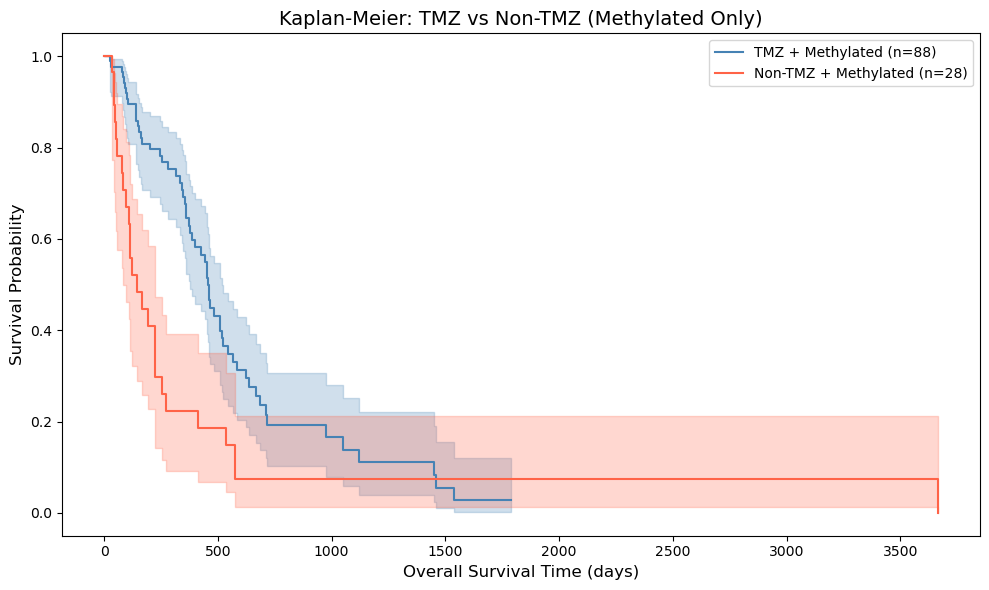

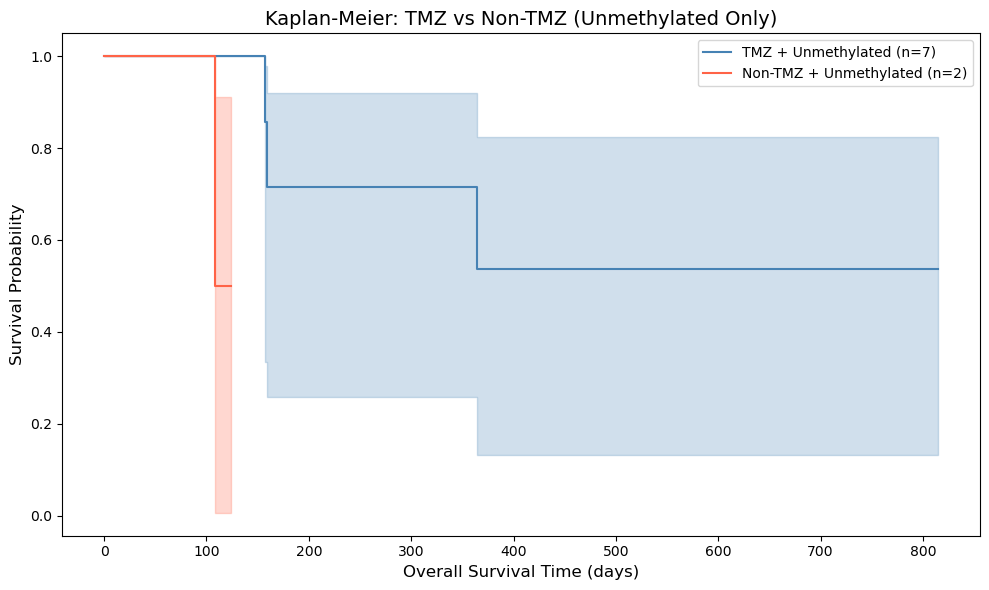

In [14]:
# ── Stratified KM Analysis: Two Separate Plots ─────────────────────────────
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# ── Plot 1: Methylated Only ─────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

for group, color in [("TMZ + Methylated", "steelblue"), ("Non-TMZ + Methylated", "tomato")]:
    subset = merged_df[merged_df["TMZ_Methylation"] == group]
    if len(subset) == 0:
        print(f"Warning: No patients found in '{group}'")
        continue
    kmf.fit(
        durations=subset["OS.time"],
        event_observed=subset["event"],
        label=f"{group} (n={len(subset)})"
    )
    kmf.plot_survival_function(ci_show=True, color=color)

plt.title("Kaplan-Meier: TMZ vs Non-TMZ (Methylated Only)", fontsize=14)
plt.xlabel("Overall Survival Time (days)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

# ── Plot 2: Unmethylated Only ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))

for group, color in [("TMZ + Unmethylated", "steelblue"), ("Non-TMZ + Unmethylated", "tomato")]:
    subset = merged_df[merged_df["TMZ_Methylation"] == group]
    if len(subset) == 0:
        print(f"Warning: No patients found in '{group}'")
        continue
    kmf.fit(
        durations=subset["OS.time"],
        event_observed=subset["event"],
        label=f"{group} (n={len(subset)})"
    )
    kmf.plot_survival_function(ci_show=True, color=color)

plt.title("Kaplan-Meier: TMZ vs Non-TMZ (Unmethylated Only)", fontsize=14)
plt.xlabel("Overall Survival Time (days)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

In [16]:
# ── Influential Observations Setup ──────────────────────────────────────────

print("Dataset shape:", cox_adj_df.shape)
print("\nIndex range:", cox_adj_df.index.min(), "to", cox_adj_df.index.max())

NameError: name 'cox_adj_df' is not defined